### Scrap notebook for testing and plotting

In [1]:
from astropy.cosmology import Planck18
%env XLA_PYTHON_CLIENT_ALLOCATOR=platform
import astropy.units as u
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
from glob import glob
import lalsimulation as lalsim
import numpy as np
import os.path as op
import sys
import pandas as pd
sys.path.append('../src/')
import weighting
import jax.numpy as jnp
import h5py
import matplotlib.pyplot as plt
from tqdm import tqdm
import scipy
import mock_observations
import intensity_models
from scipy import special
#import re
#import os
from scipy.interpolate import RegularGridInterpolator
import jax
from importlib import reload 
#reload(fisher_snrs)
jax.local_devices()
jax.config.update("jax_enable_x64", True)
from inspect import getfullargspec


env: XLA_PYTHON_CLIENT_ALLOCATOR=platform


/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
population_parameters, cosmo_true = weighting.get_pop_params('pop_configs/mock_GWTC5_evo_mmin4.txt')
log_dN_obj = intensity_models.LogDNDMDQDV
pop_params = {key: population_parameters[key] for key in getfullargspec(log_dN_obj)[0][1:] if key in population_parameters.keys()}
log_dN_func = log_dN_obj(**pop_params)
log_dN_func(6, .5, 4)

Array([-inf], dtype=float64)

In [3]:
import jax
import jax.numpy as jnp


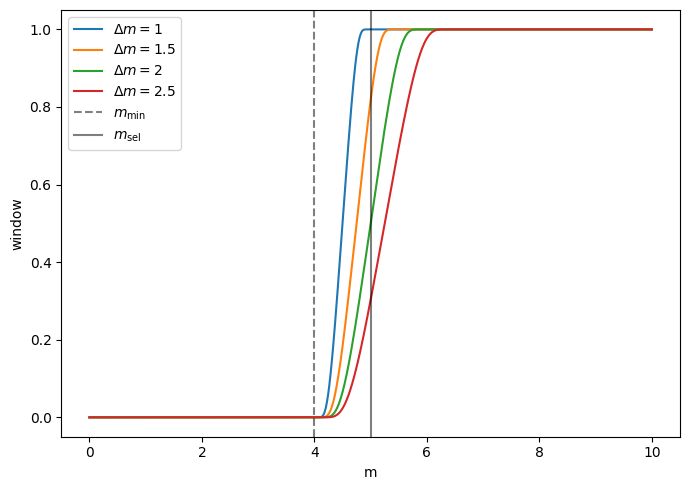

In [4]:
# Mass grid
mmin = 4.0
m_grid = np.linspace(0, 10, 1000)

# A few delta_m values to compare
delta_ms = [1, 1.5, 2, 2.5]

plt.figure(figsize=(7,5))

for delta_m in delta_ms:
    logw = intensity_models.mmin_log_smooth_turnon(
        jnp.array(m_grid),
        delta_m=delta_m,
        mmin=mmin,
    )

    w = np.exp(np.array(logw))
    plt.plot(m_grid, w, label=rf"$\Delta m={delta_m}$")

plt.axvline(mmin, color="k", ls="--", alpha=0.5, label=r"$m_{\rm min}$")
plt.axvline(5, color="black", alpha=0.5, label=r"$m_{\rm sel}$")

plt.xlabel("m")
plt.ylabel("window")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
import gc
gc.collect()
h_vals = np.linspace(0.4, 1.0, 10)
true_params={key: population_parameters[key] for key in getfullargspec(log_dN_obj)[0][1:] if key in population_parameters.keys()}
PE_files=[ '../runs/mockTC5_evo_06042026_mmin4/PE_lwerr_dm45_seldm1.h5','../runs/mockTC5_evo_06042026_mmin4/PE_lwerr_dm45_seldm2.h5' ]
sel_files=[ '../runs/mockTC5_evo_06042026_mmin4/sel_lwerr_dm45_seldm1.h5', '../runs/mockTC5_evo_06042026_mmin4/sel_lwerr_dm45_seldm2.h5' ]

In [26]:
pe_samples_mock = pd.read_hdf(PE_files[0], key='samples').iloc[0:1000]# 1.5 to 2.5 k on the 1k tests
m1s_det = np.asarray(pe_samples_mock['m1'].to_list())
qs = np.asarray(pe_samples_mock['q'].to_list())#[:, :1000]
dls =  np.asarray(pe_samples_mock['dl'].to_list())
pdraws = np.asarray(pe_samples_mock['pdraw'].to_list())
pdraws= jnp.nan_to_num(pdraws, neginf=-1e30, posinf=1e30)

sel_samples=pd.read_hdf(sel_files[0], key='true_parameters')
ndraw=sel_samples['ndraw'].iloc[0]
m1s_sel= np.array(sel_samples['m1d'].to_list())
qs_sel=np.array(sel_samples['q'].to_list())
dls_sel=np.array(sel_samples['dl'].to_list())
pdraw_sel=np.array(sel_samples['pdraw_sel'].to_list())


In [27]:
reload(intensity_models)

<module 'intensity_models' from '/mnt/home/amoran/GW_pop_cosmo_inference/scripts/../src/intensity_models.py'>

In [7]:
def full_loglik_proxy(
    h_val,
    true_params,
    m1s_det, qs, dls, log_pdraw,
    dls_sel, m1s_det_sel, qs_sel, pdraw_sel, Ndraw, keep_mask,
    Om=0.315, w=-1, zmax=6.5
):

    sample = {**true_params, 'h': h_val}

    cosmo = intensity_models.FlatwCDMCosmology(
        sample['h'], Om, w, zmax=zmax
    )
    log_dN = intensity_models.build_population_model(sample)

    # ---------------- event term ----------------

    zs = cosmo.z_of_dL(dls)
    m1s = m1s_det / (1.0 + zs)

    log_wts = (
        log_dN(m1s, qs, zs)
        - log_pdraw
        - 2.0 * jnp.log1p(zs)
        - jnp.log(cosmo.ddL_dz(zs))
        + jnp.log(cosmo.dVCdz(zs))
    )

    # ignore samples with true source-frame m2 < 4
    log_wts = jnp.where(keep_mask, log_wts, -jnp.inf)

    n_keep = jnp.sum(keep_mask, axis=1)
    n_keep = jnp.maximum(n_keep, 1)

    event_ll = jnp.sum(
        jss.logsumexp(log_wts, axis=1)
        - jnp.log(n_keep)
    )

    # ---------------- selection term ----------------
    zs_sel = cosmo.z_of_dL(dls_sel)
    m1s_sel = m1s_det_sel / (1 + zs_sel)

    log_sel_wts = (
        log_dN(m1s_sel, qs_sel, zs_sel)
        - jnp.log(pdraw_sel)
        - 2 * jnp.log1p(zs_sel)
        + jnp.log(cosmo.dVCdz(zs_sel))
        - jnp.log(cosmo.ddL_dz(zs_sel))
    )

    log_mu_sel = jss.logsumexp(log_sel_wts) - jnp.log(Ndraw)

    selection_ll = -m1s_det.shape[0] * log_mu_sel

    return event_ll + selection_ll

In [8]:
import utils
import os

In [28]:
gc.collect()

190

In [29]:
def load_true_vals(filename):
    tv = {}

    with open(filename) as f:
        for line in f:
            line = line.strip()

            if line and not line.startswith("#"):
                key, val = line.split("=", 1)
                tv[key.strip()] = float(val.strip())

    # transformed params expected by model
    tv['dkappa'] = tv['kappa'] - tv['lam']
    tv['log_fpl'] = np.log(tv['fpl'])
    tv['dmbhmax'] = tv['mbhmax'] - tv['mpisn']

    # remove unused raw params if desired
    del tv['kappa']
    del tv['fpl']
    del tv['mbhmax']

    return {k: jnp.array(v) for k, v in tv.items()}
#truth_file_name='pop_configs/mock_GWTC5_evo_mmin4_nerr.txt'
#if truth_file_name is not None:
#    print("Loading truth parameters from: ", truth_file_name)
#    truth_params=load_true_vals(truth_file_name)

In [30]:
h_grid = jnp.linspace(0.4, 1.0, 10)
zs=cosmo_true.z_of_dL(dls)
m1s_src= m1s_det / (1 + zs)
m2s_src= m1s_src*qs
mask=np.where(m2s_src>0)[0]

In [31]:
sample = {**true_params, 'h': .674}
cosmo_fid = intensity_models.FlatwCDMCosmology(
        sample['h'],  Om=0.315, w=-1, zmax=6.5)

In [32]:
zs_true = cosmo_fid.z_of_dL(dls)
m1s_src_true = m1s_det / (1.0 + zs_true)
m2s_src_true = m1s_src_true * qs

keep_mask = m2s_src_true > 0
true_params['mbh_min']=4
true_params['delta_m']=4.5

In [33]:
import jax.scipy.special as jss

In [34]:
gc.collect()

44

In [35]:
full_vals_seldm1 = jnp.array([
    full_loglik_proxy(
        float(h),
        true_params,
        m1s_det, qs, dls, pdraws,
        dls_sel, m1s_sel, qs_sel, pdraw_sel, ndraw, keep_mask
    )
    for h in h_grid
])

In [36]:
gc.collect()

15

In [37]:
pe_samples_mock = pd.read_hdf(PE_files[1], key='samples', start=0, stop=1000)# 1.5 to 2.5 k on the 1k tests
m1s_det = np.asarray(pe_samples_mock['m1'].to_list())
qs = np.asarray(pe_samples_mock['q'].to_list())#[:, :1000]
dls =  np.asarray(pe_samples_mock['dl'].to_list())
pdraws = np.asarray(pe_samples_mock['pdraw'].to_list())
pdraws= jnp.nan_to_num(pdraws, neginf=-1e30, posinf=1e30)

sel_samples=pd.read_hdf(sel_files[1], key='true_parameters')
ndraw=sel_samples['ndraw'].iloc[0]
m1s_sel= np.array(sel_samples['m1d'].to_list())
qs_sel=np.array(sel_samples['q'].to_list())
dls_sel=np.array(sel_samples['dl'].to_list())
pdraw_sel=np.array(sel_samples['pdraw_sel'].to_list())


In [38]:
gc.collect()

68

In [39]:
sample = {**true_params, 'h': .674}
cosmo_fid = intensity_models.FlatwCDMCosmology(
        sample['h'],  Om=0.315, w=-1, zmax=6.5)

zs_true = cosmo_fid.z_of_dL(dls)
m1s_src_true = m1s_det / (1.0 + zs_true)
m2s_src_true = m1s_src_true * qs

keep_mask = m2s_src_true > 0
true_params['mbh_min']=4
true_params['delta_m']=4.5

full_vals_seldm2 = jnp.array([
    full_loglik_proxy(
        float(h),
        true_params,
        m1s_det, qs, dls, pdraws,
        dls_sel, m1s_sel, qs_sel, pdraw_sel, ndraw, keep_mask
    )
    for h in h_grid
])

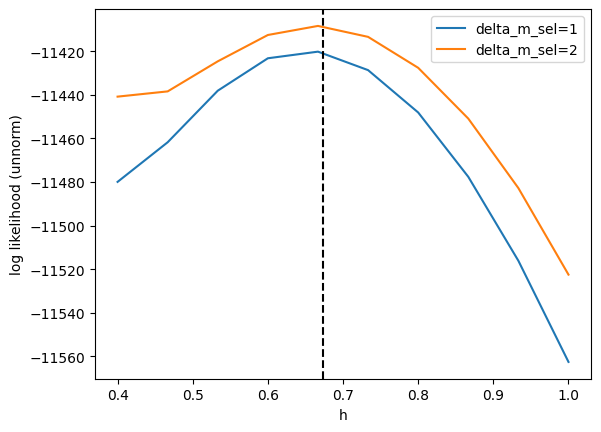

In [40]:
#plt.plot(h_grid, profile_vals, label="profile")
plt.plot(h_grid, (full_vals_seldm1), label="delta_m_sel=1")
#plt.plot(h_grid, (full_vals_pt4), label="h=.4")
plt.plot(h_grid, (full_vals_seldm2), label="delta_m_sel=2")

plt.axvline(0.674, ls="--", color="k")
plt.legend()
plt.xlabel("h")
plt.ylabel("log likelihood (unnorm)")
plt.show()

In [16]:
gc.collect()

299

In [64]:
data_paths = [#'/mnt/home/ccalvk/ceph/GWTC-3/IGWN-GWTC3p0-v2-GW*_PEDataRelease_mixed_nocosmo.h5',

            #'/mnt/home/ccalvk/ceph/GWTC-2.1/IGWN-GWTC2p1-v2-GW190*_PEDataRelease_mixed_nocosmo.h5',
            '/mnt/home/ccalvk/ceph/GWTC-4/IGWN-GWTC4p0-*-combined_PEDataRelease.hdf5']
files=[]
for path in data_paths:
        print(f'globbing path: {path}')
        files += glob(path)


globbing path: /mnt/home/ccalvk/ceph/GWTC-4/IGWN-GWTC4p0-*-combined_PEDataRelease.hdf5


In [ ]:
inj_file='../runs/mock_GWTC5_evo_mmin/inj_mockGW5.h5'
inj=pd.read_hdf(inj_file, key='true_parameters', start=0, stop=int(2e6))
m1s_inj=inj['m1']

sel_file='../runs/mock_GWTC5_evo_mmin/sel_mockGW5_evo.h5'
sel_samps=pd.read_hdf(sel_file, key='true_parameters')
m1s_sel=sel_samps['m1']

mask_low = (m1s_inj > 1.5) & (m1s_inj < 5)
mask_low_det=(m1s_sel>1.5) & (m1s_sel<5)

print(f"Injections in 1.5-5: {np.sum(mask_low)} / {len(m1s_inj)} = ", np.sum(mask_low)/len(m1s_inj))
print(f"Detection fraction: {np.sum(mask_low_det)} / {len(m1s_sel)} = ", np.sum(mask_low_det)/len(m1s_sel))

Injections in 1.5-5: 23259 / 2000000 =  0.0116295
Detection fraction: 43465 / 100496 =  0.43250477630950485


In [19]:
mpdf=scipy.stats.powerlaw(.5, loc=.4, scale=2500)
rng = np.random.default_rng()
m=mpdf.ppf(rng.uniform(low=0, high=1, size=10000))

In [ ]:
grid_file='snr_grid_aplus.npz'
grid=np.load(grid_file)
m1_grid  = grid["m1_grid"]
q_grid   = grid["q_grid"]
snr_grid = grid["snr_grid"]
dL_fid   = float(grid["dL_fid"])
log_snr_interp = RegularGridInterpolator((m1_grid, q_grid), np.log(snr_grid), bounds_error=False, fill_value=-np.inf)



/tmp/ipykernel_2637405/2473520272.py:7: RuntimeWarning: divide by zero encountered in log
  log_snr_interp = RegularGridInterpolator((m1_grid, q_grid), np.log(snr_grid), bounds_error=False, fill_value=-np.inf)


In [26]:
def get_z_obs(log_mc_obs, q_obs, theta_obs, rho_obs, rho_fun=log_snr_interp, cosmo=cosmo_true):
        
    m1_obs=np.exp(log_mc_obs)
    
    points = np.column_stack([m1_obs, q_obs])
    snr_fid = np.exp(rho_fun(points))
    dls = 1*theta_obs/1 * snr_fid*np.sqrt(3)/rho_obs
    return cosmo_true.z_of_dL(dls)

In [38]:
def get_z_obs_true(m1, q_obs, theta_obs, rho_obs, rho_fun=log_snr_interp, cosmo=cosmo_true):
        
    m1_obs=m1#np.exp(log_mc_obs)
    
    points = np.column_stack([m1_obs, q_obs])
    snr_fid = np.exp(rho_fun(points))
    dls = 1*theta_obs/1 * snr_fid*np.sqrt(3)/rho_obs
    return cosmo_true.z_of_dL(dls)

In [28]:
grid_file='snr_grid_aplus.npz'
grid=np.load(grid_file)
m1_grid  = grid["m1_grid"]
q_grid   = grid["q_grid"]
snr_grid = grid["snr_grid"]
dL_fid   = float(grid["dL_fid"])
log_snr_interp = RegularGridInterpolator((m1_grid, q_grid), np.log(snr_grid), bounds_error=False, fill_value=-np.inf)



/tmp/ipykernel_1136350/2473520272.py:7: RuntimeWarning: divide by zero encountered in log
  log_snr_interp = RegularGridInterpolator((m1_grid, q_grid), np.log(snr_grid), bounds_error=False, fill_value=-np.inf)


In [20]:
np.min(q_grid)

np.float64(0.0001)

In [29]:
m1s=np.zeros(80)+10 #np.linspace(.1, 5, 80)
qs=np.linspace(.001, .1, 80)# np.zeros_like(m1s)+.05
points = np.column_stack([m1s, qs])
snrs_out=np.exp(log_snr_interp(points))

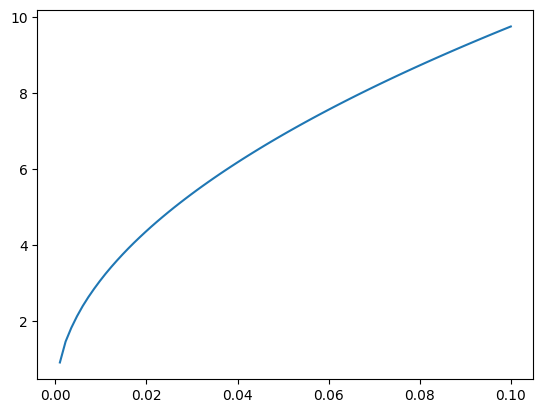

In [30]:
plt.plot(qs, snrs_out)

In [15]:
grid_file='snr_grid_326.npz'
grid=np.load(grid_file)
m1_grid  = grid["m1_grid"]
q_grid   = grid["q_grid"]
snr_grid = grid["snr_grid"]
dL_fid   = float(grid["dL_fid"])
log_snr_interp_old = RegularGridInterpolator((m1_grid, q_grid), np.log(snr_grid), bounds_error=False, fill_value=-np.inf)

/tmp/ipykernel_3913102/3585483594.py:7: RuntimeWarning: divide by zero encountered in log
  log_snr_interp_old = RegularGridInterpolator((m1_grid, q_grid), np.log(snr_grid), bounds_error=False, fill_value=-np.inf)


In [16]:
np.max(m1_grid)

np.float64(2924.999999999997)

In [14]:

masses=np.linspace(1,200, 200)
qs=np.linspace(0,1,100)

mass_snrs = np.exp(log_snr_interp([[mass, 0.5] for mass in masses]))
old_mass_snrs = np.exp(log_snr_interp_old([[mass, 0.5] for mass in masses]))

q_snrs = np.exp(log_snr_interp([[40, q] for q in qs]))
old_q_snrs = np.exp(log_snr_interp_old([[40, q] for q in qs]))

Text(0, 0.5, 'SNR')

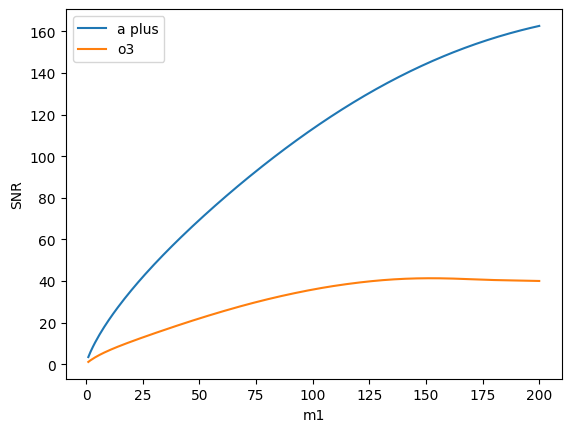

In [17]:
plt.plot(masses, mass_snrs, label='a plus')
plt.plot(masses, old_mass_snrs, label='o3')
plt.legend()
plt.xlabel('m1')
plt.ylabel('SNR')

Text(0, 0.5, 'SNR')

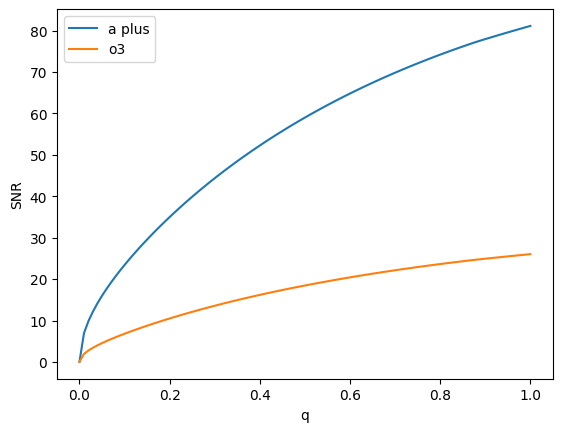

In [18]:
plt.plot(qs, q_snrs, label='a plus')
plt.plot(qs, old_q_snrs, label='o3')
plt.legend()
plt.xlabel('q')
plt.ylabel('SNR')

### Errors

In [14]:
def get_X_logmc(M, SNR, sigma_M):
    """
    Take chirp mass, SNR, and upper and lower bounds on chirp mass.
    Propogate those bounds to log chirp mass bounds
    solve for the linear factor we would use to go from SNR to sigma_log_mc

    Also works for log chirp mass!
    """
    sigma_M=jnp.array(sigma_M)
    log_mc=jnp.log(M)
    sigma_log_mc=np.mean(sigma_M/M) #propogate error and collapse to symmetric errors 
    return SNR*sigma_log_mc  #sigma_log_mc= X/SNR

def get_X_q(SNR, sigma_q):
    """
    solve for the linear factor we would use to go from SNR to sigma_q
    This is old, we now use log_q error
    """
    sigma_q=np.mean(sigma_q) #collapse to symmetric
    return SNR*sigma_q #sigma_q= X/SNR


In [99]:
# Event data: (SNR, M, [lower_error, upper_error])
# all 35 events here: https://gwosc.org/eventapi/html/GWTC-3-confident/
events = [(4.5, 15.0, [29.5, 4.0]),
    (10.3, 8.75, [0.62, 0.55]),
    (17.8, 6.6, [2.4, 2.0]),
    (4.7, 34, [44, 18]),
    (7.8, 17.5, [3.5, 3.0]),
    (10.8, 23.4, [4.7, 3.0]),
    (12.5, 14.2, [1.5, 1.4]),
    (20.0, 31.1, [3.3, 2.7]),
    (8.5, 28.2, [7.3, 5.1]),
    (7.2, 62, [23, 15]),
    (10.7, 27.6, [5.6, 3.8]),
    (8.1, 32.9, [9.3, 8.5]),
    (8.4, 6.56, [0.38, 0.40]),
    (9.6, 26.7, [6.0, 4.2]),
    (7.4, 19.8, [10.5, 5.2]),
    (10.8, 27.7, [3.7, 3.1]),
    (10.8, 7.49, [0.24, 0.2]),
    (26.8, 27.2, [2.1, 2.3]),
    (10.6, 32.0, [7.5, 5.5]),
    (11.3, 2.43, [0.05, 0.07]),
    (19.8, 27.4, [2.6, 2.1]),
    (10.4, 36.5, [8.2, 5.6]),
    (12.5, 33.8, [7.1, 5.0]),
    (9.1, 4.31, [0.12, 0.17]),
    (18.6, 8.33, [0.22, 0.19]),
    (11.2, 18.4, [2.2, 1.7]),
    (17.4, 8.56, [0.41, 0.28]),
    (8.9, 19.8, [3.6, 3.2]),
    (13.1, 7.31, [0.43, 0.28]),
    (9.2, 29.9, [11.7, 9.1]),
    (8.3, 8.65, [0.95, 0.71]),
    (7.9, 10.7, [1.1, 1.0]),
    (17.3, 47.5, [9.6, 7.5]),
    (9.7, 7.82, [0.61, 0.45]),
    (8.9, 8.34, [0.66, 0.57])]

Xs_1 = [get_X_logmc(M, SNR, errors) for SNR, M, errors in events]

print("Mean X:", np.mean(Xs_1))
print("Std X:", np.std(Xs_1))

Mean X: 1.767974784089777
Std X: 1.3006138540035586


In [100]:
events_q= [(4.5, 0.3, [0.7, 0.7]),
(10.3, 0.6, [0.4, 0.4]),
(17.8, 0.8, [0.2, 0.2]),
(4.7, 0.4, [0.8, 0.8]),
(7.8, 0.5, [0.3, 0.3]),
(10.8, 0.5, [0.2, 0.2]),
(12.5, 0.7, [0.2, 0.2]),
(20.0, 0.8, [0.2, 0.2]),
(8.5, 0.7, [0.3, 0.3]),
(7.2, 0.7, [0.4, 0.4]),
(10.7, 0.7, [0.3, 0.3]),
(8.1, 0.6, [0.4, 0.4]),
(8.4, 0.117427385892116, [0.0347841574263123, 0.0347841574263123]),
(9.6, 0.8, [0.3, 0.3]),
(7.4, 0.2, [0.3, 0.3]),
(10.8, 0.7, [0.2, 0.2]),
(10.8, 0.7, [0.2, 0.2]),
(26.8, 0.8, [0.2, 0.2]),
(10.6, 0.8, [0.3, 0.3]),
(11.3, 0.244067796610169, [0.133543137064012, 0.133543137064012]),
(19.8, 0.8, [0.2, 0.2]),
(10.4, 0.7, [0.3, 0.3]),
(12.5, 0.8, [0.3, 0.3]),
(9.1, 0.037620578778135, [0.00367611097618323, 0.00367611097618323]),
(18.6, 0.6, [0.2, 0.2]),
(11.2, 0.7, [0.2, 0.2]),
(17.4, 0.7, [0.2, 0.2]),
(8.9, 0.7, [0.3, 0.3]),
(13.1, 0.6, [0.2, 0.2]),
(9.2, 0.5, [0.4, 0.4]),
(8.3, 0.7, [0.3, 0.3]),
(7.9, 0.2, [0.1, 0.1]),
(17.3, 0.7, [0.2, 0.2]),
(9.7, 0.7, [0.2, 0.2]),
(8.9, 0.7, [0.3, 0.3])]



Xs_q = [get_X_q(SNR, errors) for SNR, _, errors in events_q]
SNRS=[]
for i in range(len(events_q)):
    SNRS.append(events_q[i][0])
print("Mean X:", np.mean(Xs_q)) 
print("Std X:", np.std(Xs_q))

Mean X: 2.7958479137453605
Std X: 1.0628760418098722


### LIGO way

In [14]:
import weighting
import h5py
from astropy.cosmology import Planck18
import jax.scipy.special as jss
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

In [15]:
reload(weighting)

<module 'weighting' from '/mnt/home/amoran/GW_pop_cosmo_inference/src/weighting.py'>

In [68]:
#('/home/reed.essick/rates+pop/o3-sensitivity-estimates/LIGO-T2100113-v11/endo3_bbhpop-LIGO-T2100113-v11.hdf5', nsamp=None, desired_pop_wt=None)
m1, q, z, a1, a2, cos_tilt1, cos_tilt2, pdraw, ndraw = weighting.sel_samples_mock('../endo3_bbhpop-LIGO-T2100113-v12.hdf5', 
                                                                                  detectors=detectors, SNR=8, 
                                                                                  sensitivity='o3_PSD',  SNR_load=True,
                                                                                  SNR_write=False,  SNR_file='LIGO_SNR_1222.txt')
df = pd.DataFrame({'m1': m1, 'q': q, 'z': z, 'a1': a1, 'a2':a2, 'cos_tilt_1': cos_tilt1, 'cos_tilt_2': cos_tilt2, 'pdraw_m1sqz': pdraw, 'ndraw': ndraw}) 

In [70]:
df['dm1sz_dm1ddl'] = 1/ ((1+df['z'].values))*cosmo.ddL_dz(df['z'].values)
# weighting.dm1sz_dm1ddl(df['z'])#gives us factor to go soruce to detector frame mass, and z to dL in prior
df.to_hdf('./selection_samples_o3_1230.h5', 'samples')

/tmp/ipykernel_1659843/2770026045.py:3: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  df.to_hdf('./selection_samples_o3_1230.h5', 'samples')
